# UAS Big Data — Prediksi Tingkat Stres (Growing_Stress) pada Mental Health Dataset

**Nama:** Abdullah Al Manan
**Program Studi:** Teknik Informatika, Fakultas Ilmu Komputer, Universitas Mercu Buana
**Mata Kuliah:** Big Data
**Jenis Tugas:** Individu (UAS)

---

## Deskripsi Proyek

Notebook ini berisi analisis dan pemodelan *machine learning* untuk memprediksi tingkat stres yang terus meningkat (**Growing_Stress**) pada responden survei kesehatan mental, dengan tiga kelas target: `Yes`, `No`, dan `Maybe`.

Dataset yang digunakan adalah **Mental Health Dataset** yang berisi ±292.364 baris data survei terkait kondisi kesehatan mental, kebiasaan kerja, dan gaya hidup responden.

### Tahapan yang dilakukan:
1. **Exploratory Data Analysis (EDA)**
2. **Data Preprocessing** (missing value, duplikasi, encoding, feature engineering, feature selection, standardisasi, split data)
3. **Pemodelan Machine Learning** dengan 4 algoritma: **Logistic Regression, Random Forest, K-Nearest Neighbors (KNN), dan Naive Bayes**
4. **Evaluasi Model** (parameter, hasil training, confusion matrix, classification report)
5. **Kesimpulan & Perbandingan Model**


## 1. Import Library

Pada tahap ini, seluruh pustaka (*library*) yang dibutuhkan untuk keperluan manipulasi data, visualisasi, preprocessing, dan pemodelan *machine learning* diimpor terlebih dahulu.

In [3]:
# Manipulasi data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.feature_selection import SelectKBest, chi2

# Model Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# Evaluasi
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                              precision_score, recall_score, f1_score, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

# Palet warna kustom yang lebih modern dan konsisten di seluruh notebook
PALETTE = ['#6C5CE7', '#00B894', '#0984E3', '#FDCB6E', '#E17055',
           '#D63031', '#00CEC9', '#A29BFE', '#FAB1A0', '#55EFC4']

sns.set_theme(style='white', font_scale=1.02)
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#dfe6e9',
    'axes.linewidth': 1.0,
    'axes.labelcolor': '#2d3436',
    'axes.labelweight': 'medium',
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.titlecolor': '#2d3436',
    'axes.titlepad': 14,
    'xtick.color': '#636e72',
    'ytick.color': '#636e72',
    'font.family': 'DejaVu Sans',
    'grid.color': '#f1f2f6',
    'grid.linewidth': 1.0,
    'legend.frameon': False,
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Pengaturan tampilan
pd.set_option('display.max_columns', None)

print("Seluruh library berhasil diimpor & tema visualisasi kustom diaktifkan.")

Seluruh library berhasil diimpor & tema visualisasi kustom diaktifkan.


## 2. Membaca Dataset

Dataset dibaca menggunakan `pandas.read_csv()`, kemudian dilakukan pengecekan awal terhadap ukuran data, tipe data, dan lima baris pertama untuk memahami struktur dataset.

In [4]:
df = pd.read_csv('Mental Health Dataset.csv')

print(f"Ukuran dataset: {df.shape[0]} baris dan {df.shape[1]} kolom")
df.head()

Ukuran dataset: 292364 baris dan 17 kolom


,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [5]:
# Informasi umum mengenai tipe data dan jumlah data non-null pada setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

In [6]:
# Statistik deskriptif untuk seluruh kolom (karena mayoritas kategorikal, describe() menampilkan value kategorikal)
df.describe(include='all')

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
count,292364,292364,292364,292364,287162,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364,292364
unique,580,2,35,5,2,2,2,5,3,3,3,3,2,3,3,3,3
top,8/27/2014 11:43,Male,United States,Housewife,No,No,Yes,1-14 days,Maybe,Yes,No,Medium,No,No,Maybe,No,No
freq,2384,239850,171308,66351,257994,176832,147606,63548,99985,109523,104018,101064,154328,105843,103393,232166,118886


## 3. Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan eksplorasi data untuk memahami karakteristik, pola, dan distribusi setiap variabel sebelum masuk ke tahap preprocessing dan pemodelan.

### 3.1 Pengecekan Missing Value

In [7]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct.round(2)})
missing_df = missing_df[missing_df['Jumlah Missing'] > 0].sort_values('Jumlah Missing', ascending=False)
print("Kolom dengan missing value:")
missing_df

Kolom dengan missing value:


,Jumlah Missing,Persentase (%)
self_employed,5202,1.78


**Interpretasi:** Hanya kolom `self_employed` yang memiliki missing value, yaitu sekitar 1,78% dari total data. Persentase ini relatif kecil sehingga penanganannya tidak akan terlalu memengaruhi distribusi data secara keseluruhan.

### 3.2 Pengecekan Data Duplikat

In [8]:
jumlah_duplikat = df.duplicated().sum()
print(f"Jumlah baris duplikat: {jumlah_duplikat}")
print(f"Persentase duplikat: {jumlah_duplikat / len(df) * 100:.2f}%")

Jumlah baris duplikat: 2313
Persentase duplikat: 0.79%


### 3.3 Distribusi Variabel Target (Growing_Stress)

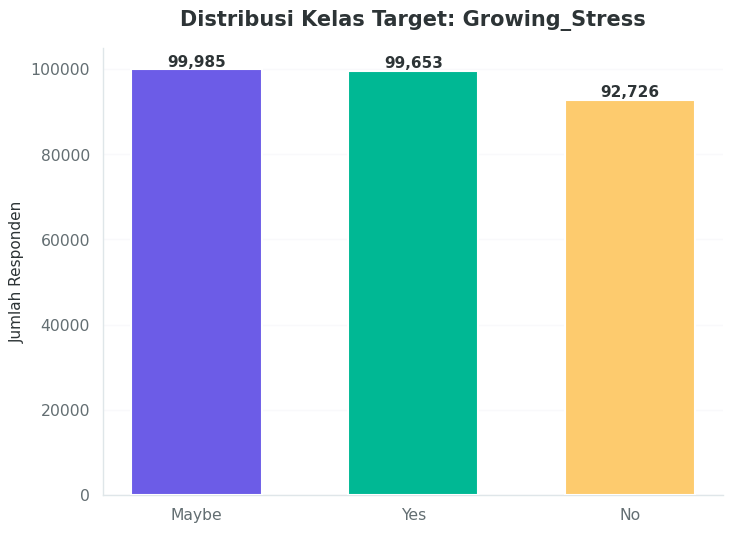

Growing_Stress
Maybe    99985
Yes      99653
No       92726
Name: count, dtype: int64

Growing_Stress
Maybe    34.2
Yes      34.1
No       31.7
Name: proportion, dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(7.5,5.5))
warna_target = ['#6C5CE7', '#00B894', '#FDCB6E']
counts = df['Growing_Stress'].value_counts()
bars = ax.bar(counts.index, counts.values, color=warna_target, width=0.6,
              edgecolor='white', linewidth=1.5, zorder=3)

for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{int(h):,}', (bar.get_x() + bar.get_width()/2, h),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2d3436')

ax.set_title('Distribusi Kelas Target: Growing_Stress', fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('')
ax.set_ylabel('Jumlah Responden', fontsize=11)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(df['Growing_Stress'].value_counts())
print()
print(df['Growing_Stress'].value_counts(normalize=True).round(3) * 100)

**Interpretasi:** Distribusi kelas target cukup seimbang (*balanced*), dengan proporsi masing-masing kelas berkisar antara 31% - 34%. Hal ini menguntungkan karena model tidak akan bias secara signifikan terhadap kelas mayoritas, sehingga metrik akurasi tetap dapat diandalkan sebagai salah satu tolok ukur evaluasi.

### 3.4 Distribusi Variabel Kategorikal Lainnya

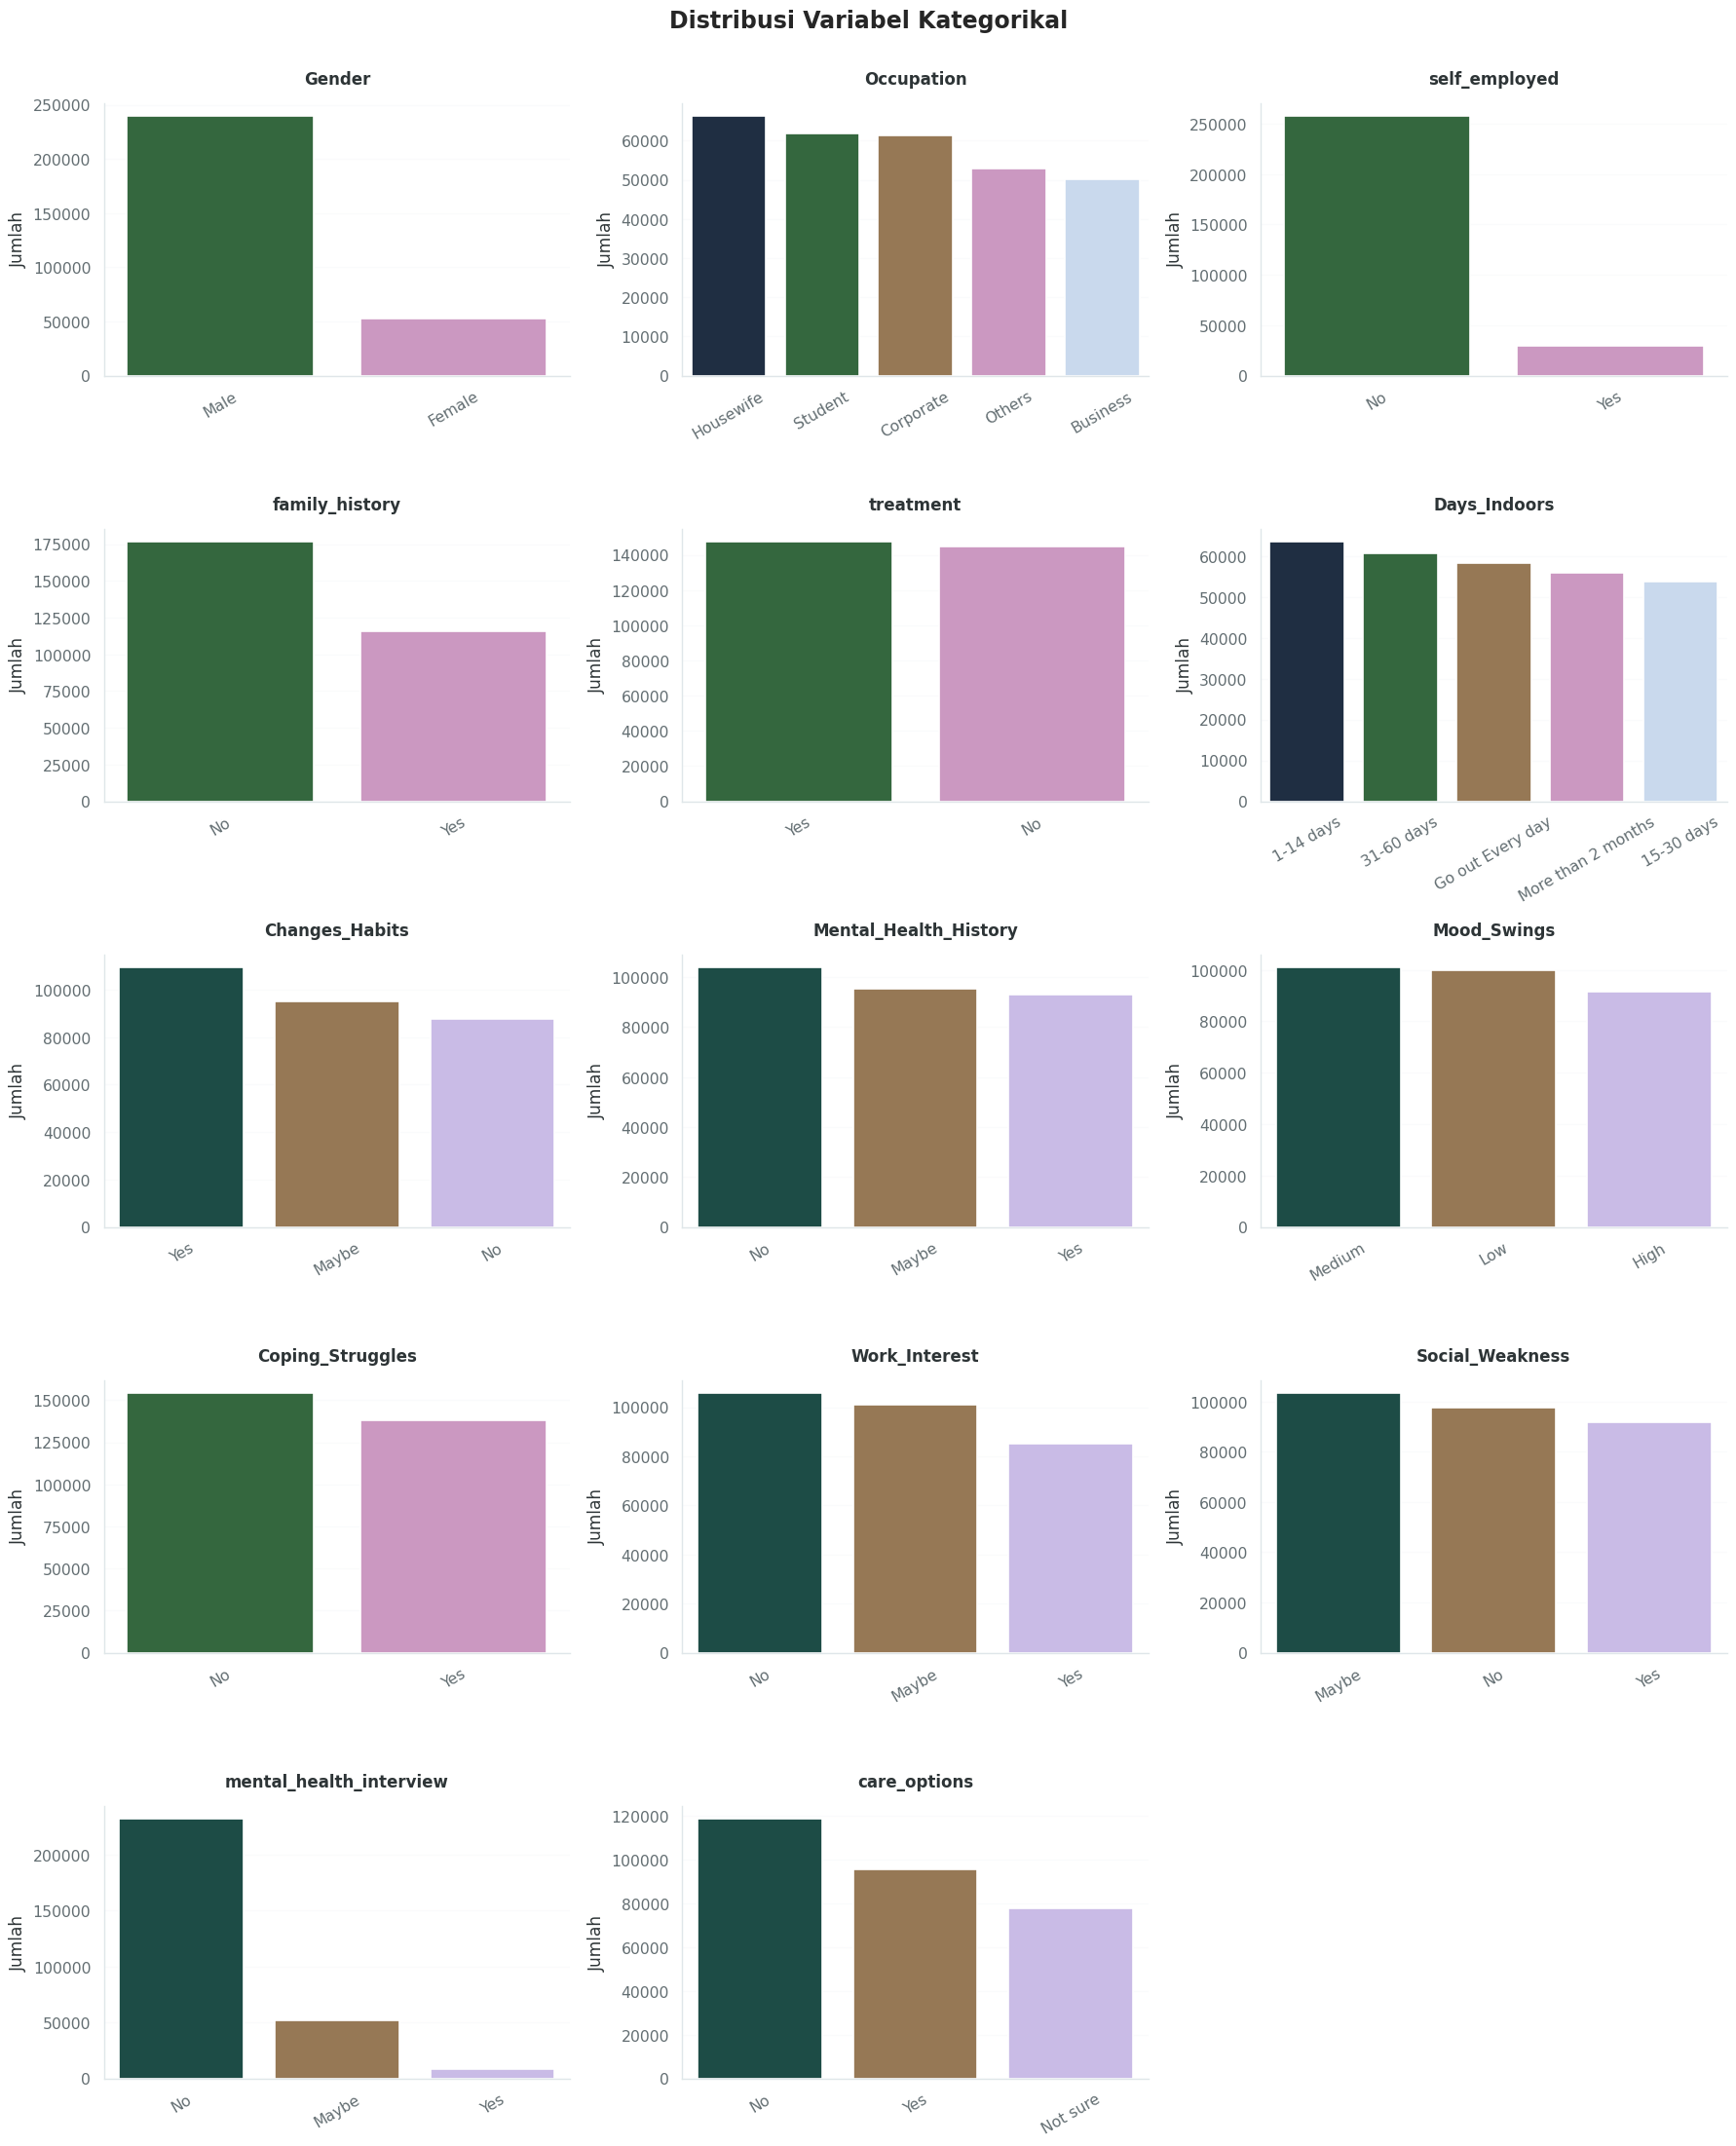

In [10]:
kategori_cols = ['Gender', 'Occupation', 'self_employed', 'family_history', 'treatment',
                  'Days_Indoors', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings',
                  'Coping_Struggles', 'Work_Interest', 'Social_Weakness',
                  'mental_health_interview', 'care_options']

fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for i, col in enumerate(kategori_cols):
    order = df[col].value_counts().index
    warna = sns.color_palette('cubehelix', len(order))
    sns.countplot(data=df, x=col, order=order, ax=axes[i], palette=warna, edgecolor='white', linewidth=1.2)
    axes[i].set_title(col, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(axis='y', alpha=0.3)
    axes[i].set_axisbelow(True)

# Kosongkan subplot sisa
for j in range(len(kategori_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribusi Variabel Kategorikal', fontsize=17, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

**Interpretasi:** Sebagian besar variabel kategorikal memiliki distribusi yang cukup merata di antara kelas-kelasnya (misalnya `Mood_Swings`, `Days_Indoors`, `Mental_Health_History`). Variabel `Gender` dan `self_employed` didominasi oleh satu kategori, yang perlu diperhatikan pada saat encoding dan interpretasi hasil model.

### 3.5 Distribusi Negara Responden (Top 10)

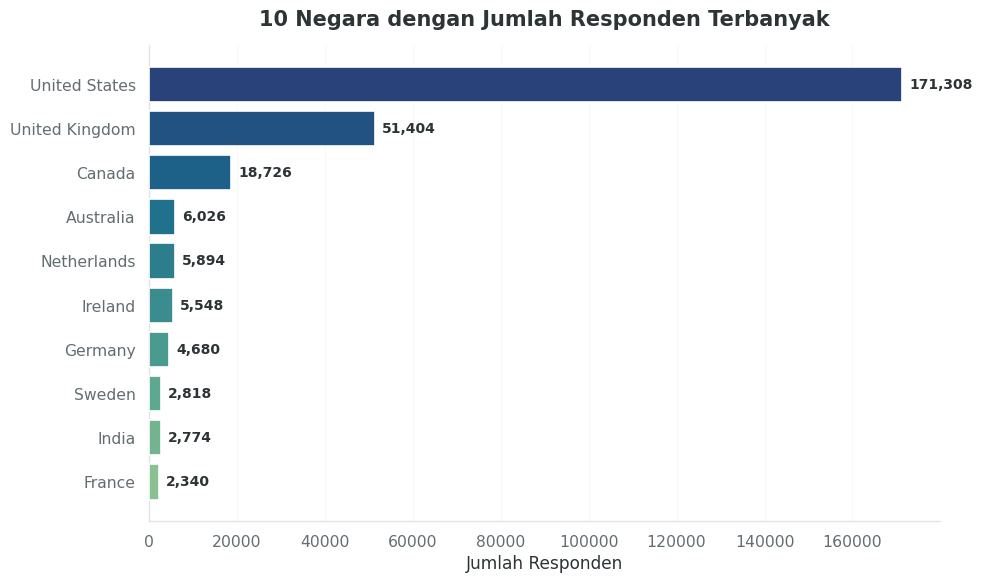

In [11]:
top_country = df['Country'].value_counts().head(10)
warna_country = sns.color_palette('crest', len(top_country))[::-1]

fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(top_country.index[::-1], top_country.values[::-1], color=warna_country[::-1],
               edgecolor='white', linewidth=1.2, zorder=3)
for bar in bars:
    w = bar.get_width()
    ax.annotate(f'{int(w):,}', (w, bar.get_y() + bar.get_height()/2),
                ha='left', va='center', fontsize=10, fontweight='bold', color='#2d3436', xytext=(5,0), textcoords='offset points')

ax.set_title('10 Negara dengan Jumlah Responden Terbanyak', fontsize=15, fontweight='bold')
ax.set_xlabel('Jumlah Responden')
ax.set_ylabel('')
ax.grid(axis='x', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Interpretasi:** Responden didominasi oleh Amerika Serikat dan Inggris, yang menunjukkan bahwa dataset ini kemungkinan berasal dari survei berbasis platform berbahasa Inggris. Hal ini perlu menjadi catatan terkait generalisasi hasil model terhadap populasi di luar negara-negara tersebut.

### 3.6 Analisis Bivariat: Hubungan Variabel Kategorikal terhadap Growing_Stress

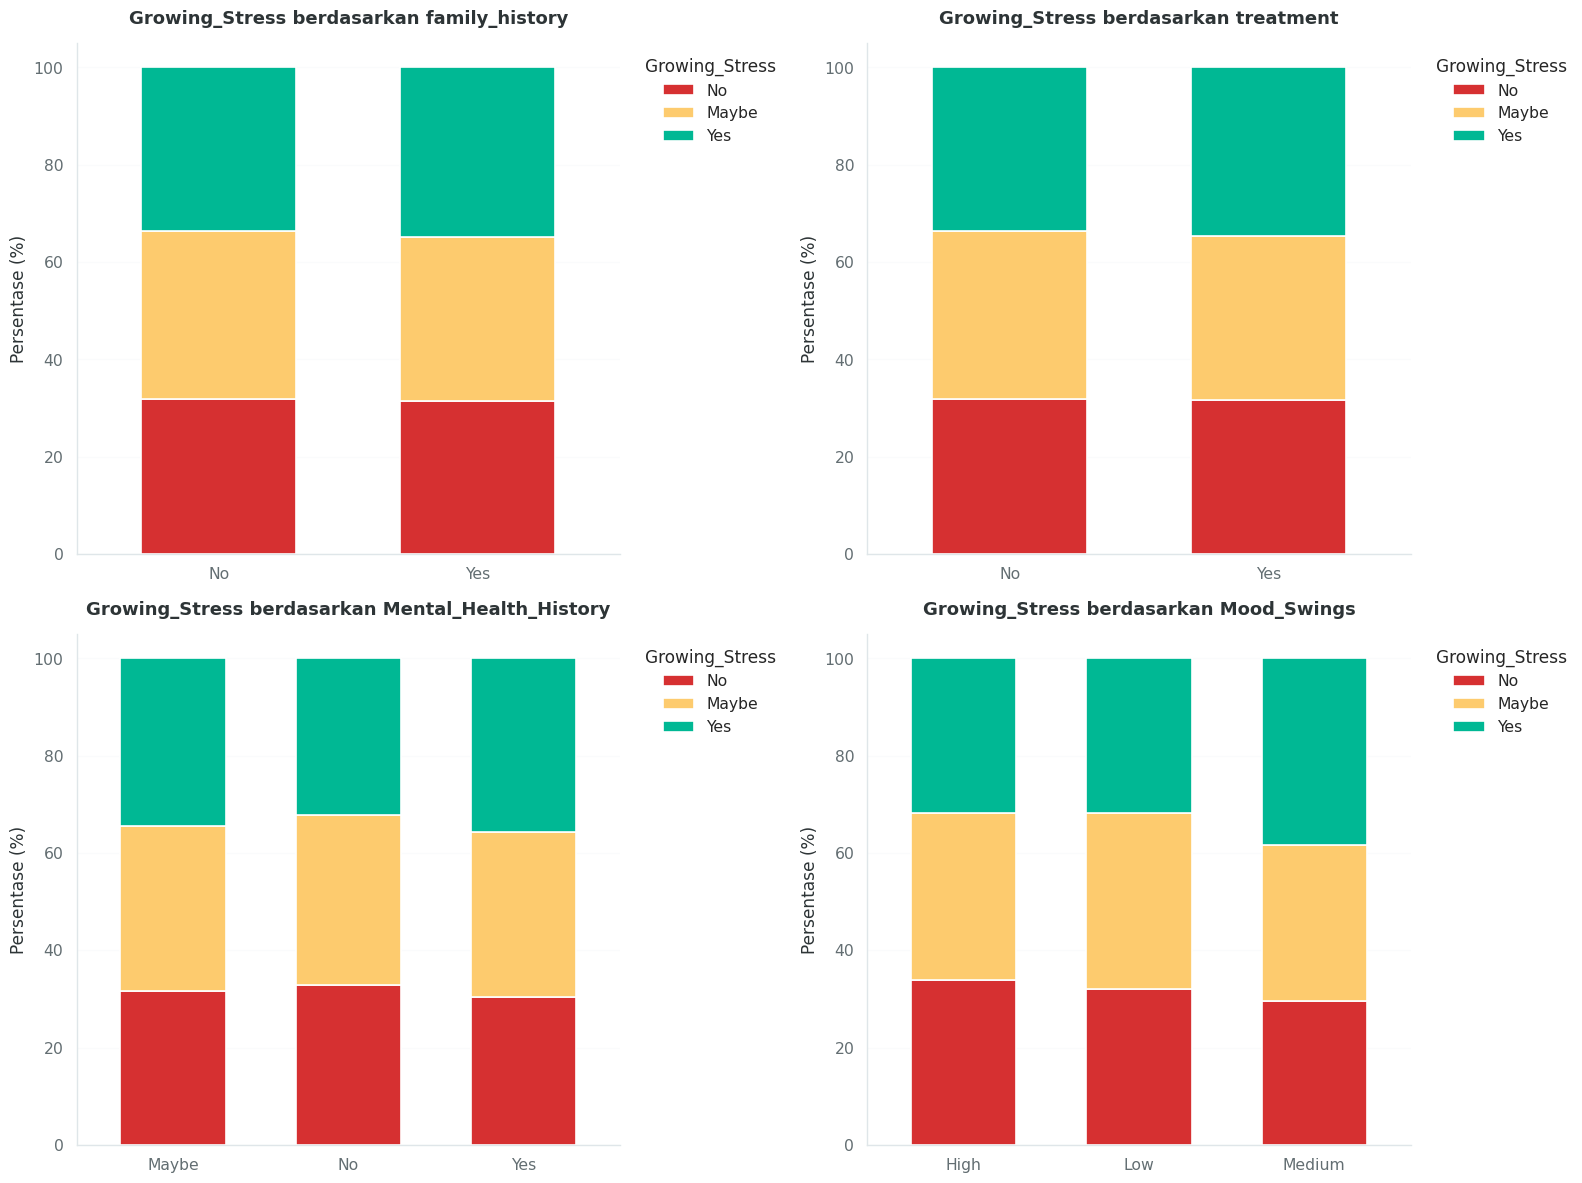

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
warna_stack = ['#D63031', '#FDCB6E', '#00B894']

pairs = ['family_history', 'treatment', 'Mental_Health_History', 'Mood_Swings']
for i, col in enumerate(pairs):
    ax = axes.flatten()[i]
    ct = pd.crosstab(df[col], df['Growing_Stress'], normalize='index') * 100
    ct = ct[['No', 'Maybe', 'Yes']]
    ct.plot(kind='bar', stacked=True, ax=ax, color=warna_stack, edgecolor='white', linewidth=1.2, width=0.6)
    ax.set_title(f'Growing_Stress berdasarkan {col}', fontweight='bold', fontsize=13)
    ax.set_xlabel('')
    ax.set_ylabel('Persentase (%)')
    ax.legend(title='Growing_Stress', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.tick_params(axis='x', rotation=0)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Interpretasi:** Responden dengan riwayat keluarga (`family_history` = Yes) dan riwayat kesehatan mental (`Mental_Health_History` = Yes) menunjukkan kecenderungan proporsi `Growing_Stress = Yes` yang lebih tinggi dibandingkan yang tidak memiliki riwayat tersebut. Hal ini mengindikasikan bahwa kedua variabel tersebut berpotensi menjadi prediktor penting dalam model.

### 3.7 Feature Engineering Awal dari Timestamp (Eksplorasi)

Rentang waktu survei: 2014-08-27 11:29:00 hingga 2016-02-01 23:04:00


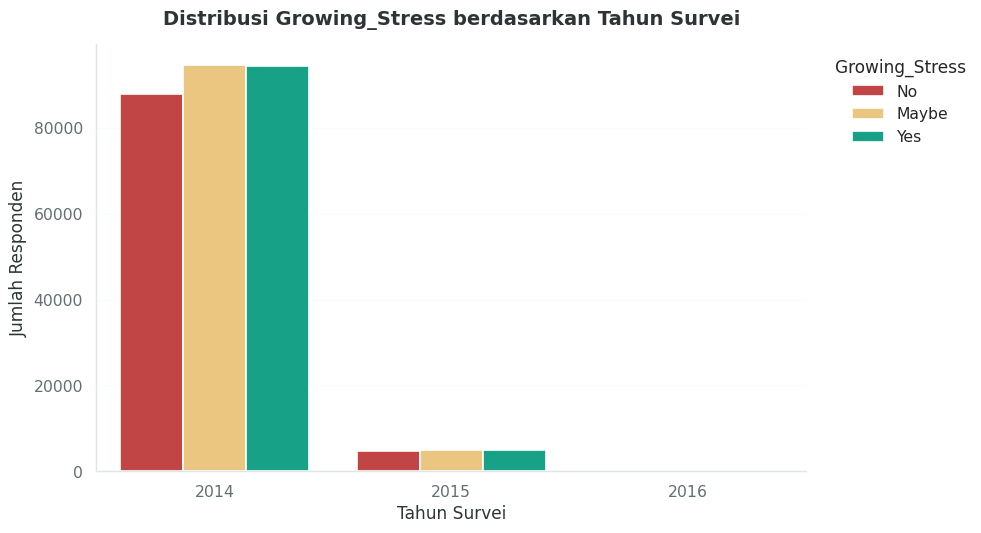

In [13]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
print("Rentang waktu survei:", df['Timestamp'].min(), "hingga", df['Timestamp'].max())

df['survey_year'] = df['Timestamp'].dt.year
df['survey_month'] = df['Timestamp'].dt.month
df['survey_hour'] = df['Timestamp'].dt.hour

fig, ax = plt.subplots(figsize=(10,5.5))
sns.countplot(data=df, x='survey_year', hue='Growing_Stress', hue_order=['No','Maybe','Yes'],
              palette=['#D63031', '#FDCB6E', '#00B894'], edgecolor='white', linewidth=1.2, ax=ax)
ax.set_title('Distribusi Growing_Stress berdasarkan Tahun Survei', fontweight='bold', fontsize=14)
ax.set_xlabel('Tahun Survei')
ax.set_ylabel('Jumlah Responden')
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
ax.legend(title='Growing_Stress', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Interpretasi:** Mayoritas data survei dikumpulkan pada tahun 2014, dengan proporsi kelas target yang relatif konsisten antar tahun. Fitur waktu survei (`survey_year`, `survey_month`, `survey_hour`) akan dievaluasi kembali pada tahap *feature selection* untuk menentukan apakah layak dipertahankan sebagai prediktor.

## 4. Data Preprocessing

Tahap ini mencakup seluruh proses pembersihan dan transformasi data agar siap digunakan dalam pemodelan *machine learning*, meliputi: penanganan *missing value*, penghapusan duplikat, *encoding* variabel kategorikal, *feature engineering*, *feature selection*, standardisasi, serta pembagian data latih dan uji.

### 4.1 Missing Value Handling

Kolom `self_employed` memiliki missing value. Karena variabel ini bertipe kategorikal biner (Yes/No), penanganan dilakukan dengan mengisi nilai kosong menggunakan **modus (nilai yang paling sering muncul)**.

In [14]:
print("Modus self_employed:", df['self_employed'].mode()[0])
df['self_employed'] = df['self_employed'].fillna(df['self_employed'].mode()[0])

print("\nJumlah missing value setelah imputasi:")
print(df.isna().sum().sum())

Modus self_employed: No

Jumlah missing value setelah imputasi:
0


### 4.2 Duplicate Removal

In [15]:
print(f"Jumlah baris sebelum penghapusan duplikat: {df.shape[0]}")

df = df.drop_duplicates()

print(f"Jumlah baris setelah penghapusan duplikat: {df.shape[0]}")

Jumlah baris sebelum penghapusan duplikat: 292364
Jumlah baris setelah penghapusan duplikat: 290051


### 4.3 Feature Engineering

Beberapa fitur baru dibuat untuk memperkaya informasi yang dapat digunakan model:

1. `survey_year`, `survey_month`, `survey_hour` — sudah dibuat pada tahap EDA dari kolom `Timestamp`.
2. `risk_score` — skor gabungan sederhana yang menjumlahkan indikator risiko kesehatan mental (`family_history`, `treatment`, `Mental_Health_History`, `Coping_Struggles`) untuk menangkap interaksi antar variabel risiko dalam satu fitur numerik.
3. Kolom `Timestamp` asli dihapus karena sudah direpresentasikan oleh fitur waktu turunannya dan tidak relevan digunakan langsung sebagai prediktor.

In [16]:
def hitung_risk_score(row):
    skor = 0
    skor += 1 if row['family_history'] == 'Yes' else 0
    skor += 1 if row['treatment'] == 'Yes' else 0
    skor += 1 if row['Mental_Health_History'] == 'Yes' else 0
    skor += 1 if row['Coping_Struggles'] == 'Yes' else 0
    return skor

df['risk_score'] = df.apply(hitung_risk_score, axis=1)

# Hapus kolom Timestamp karena sudah direpresentasikan oleh fitur turunannya
df = df.drop(columns=['Timestamp'])

print("Distribusi risk_score:")
print(df['risk_score'].value_counts().sort_index())
df[['family_history', 'treatment', 'Mental_Health_History', 'Coping_Struggles', 'risk_score']].head()

Distribusi risk_score:
risk_score
0    41256
1    88549
2    92232
3    55110
4    12904
Name: count, dtype: int64


,family_history,treatment,Mental_Health_History,Coping_Struggles,risk_score
0,No,Yes,Yes,No,2
1,Yes,Yes,Yes,No,3
2,Yes,Yes,Yes,No,3
3,Yes,Yes,Yes,No,3
4,Yes,Yes,Yes,No,3


### 4.4 Encoding Variabel Kategorikal

Karena seluruh fitur prediktor bersifat kategorikal (nominal maupun ordinal), dilakukan **Label Encoding** untuk mengubah nilai kategorikal menjadi numerik agar dapat diproses oleh algoritma *machine learning*. Label encoder untuk setiap kolom disimpan agar dapat ditelusuri kembali mapping-nya.

In [17]:
df_encoded = df.copy()

kolom_kategorikal = df_encoded.select_dtypes(include='object').columns.tolist()
print("Kolom yang akan di-encode:", kolom_kategorikal)

label_encoders = {}
for col in kolom_kategorikal:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le

df_encoded.head()

Kolom yang akan di-encode: ['Gender', 'Country', 'Occupation', 'self_employed', 'family_history', 'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits', 'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles', 'Work_Interest', 'Social_Weakness', 'mental_health_interview', 'care_options']


,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options,survey_year,survey_month,survey_hour,risk_score
0,0,34,1,0,0,1,0,2,1,2,2,0,1,2,1,1,2014,8,11,2
1,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,0,2014,8,11,3
2,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2,2014,8,11,3
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2,2014,8,11,3
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2,2014,8,11,3


In [18]:
# Menampilkan mapping label encoding untuk variabel target sebagai referensi
print("Mapping kelas Growing_Stress:")
for i, kelas in enumerate(label_encoders['Growing_Stress'].classes_):
    print(f"  {kelas} -> {i}")

Mapping kelas Growing_Stress:
  Maybe -> 0
  No -> 1
  Yes -> 2


### 4.5 Feature Selection

Feature selection dilakukan menggunakan uji statistik **Chi-Square (chi2)** dari `SelectKBest` untuk mengukur seberapa kuat hubungan setiap fitur kategorikal (yang telah di-encode) terhadap variabel target `Growing_Stress`. Fitur dengan skor Chi-Square tertinggi dianggap paling relevan untuk dipertahankan dalam model.

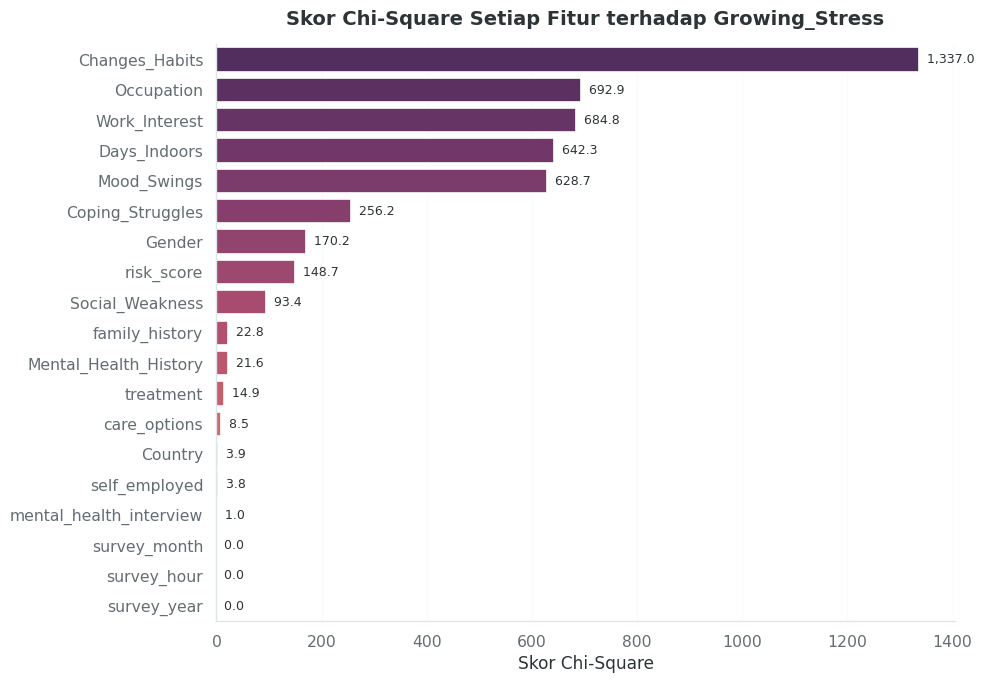

,Fitur,Skor Chi-Square
7,Changes_Habits,1337.023024
2,Occupation,692.887358
11,Work_Interest,684.812207
6,Days_Indoors,642.320063
9,Mood_Swings,628.744916
10,Coping_Struggles,256.223409
0,Gender,170.165829
18,risk_score,148.668190
12,Social_Weakness,93.379836
4,family_history,22.826142


In [19]:
X_full = df_encoded.drop(columns=['Growing_Stress'])
y_full = df_encoded['Growing_Stress']

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_full, y_full)

skor_fitur = pd.DataFrame({
    'Fitur': X_full.columns,
    'Skor Chi-Square': selector.scores_
}).sort_values('Skor Chi-Square', ascending=False)

plt.figure(figsize=(10,7))
warna_chi = sns.color_palette('flare', len(skor_fitur))[::-1]
ax = sns.barplot(data=skor_fitur, x='Skor Chi-Square', y='Fitur', palette=warna_chi, edgecolor='white', linewidth=1.2)
for i, v in enumerate(skor_fitur['Skor Chi-Square']):
    ax.text(v, i, f'  {v:,.1f}', va='center', fontsize=9, color='#2d3436')
plt.title('Skor Chi-Square Setiap Fitur terhadap Growing_Stress', fontweight='bold', fontsize=14)
plt.xlabel('Skor Chi-Square')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

skor_fitur

In [20]:
# Memilih fitur dengan kontribusi yang relevan (skor Chi-Square > 0, dan membuang fitur waktu survei
# yang secara konseptual tidak relevan sebagai penyebab tingkat stres)
fitur_dibuang = ['survey_year', 'survey_month', 'survey_hour']
fitur_terpilih = [f for f in skor_fitur['Fitur'] if f not in fitur_dibuang]

print(f"Jumlah fitur awal: {X_full.shape[1]}")
print(f"Jumlah fitur terpilih: {len(fitur_terpilih)}")
print("\nFitur yang digunakan untuk pemodelan:")
print(fitur_terpilih)

X = df_encoded[fitur_terpilih]
y = df_encoded['Growing_Stress']

Jumlah fitur awal: 19
Jumlah fitur terpilih: 16

Fitur yang digunakan untuk pemodelan:
['Changes_Habits', 'Occupation', 'Work_Interest', 'Days_Indoors', 'Mood_Swings', 'Coping_Struggles', 'Gender', 'risk_score', 'Social_Weakness', 'family_history', 'Mental_Health_History', 'treatment', 'care_options', 'Country', 'self_employed', 'mental_health_interview']


**Interpretasi:** Fitur-fitur turunan waktu survei (`survey_year`, `survey_month`, `survey_hour`) dikeluarkan dari pemodelan karena secara konseptual merepresentasikan waktu pengisian survei, bukan karakteristik responden yang secara logis memengaruhi tingkat stres. Fitur yang dipertahankan adalah fitur-fitur yang merepresentasikan kondisi psikologis, riwayat, dan gaya hidup responden.

### 4.6 Standardisasi Fitur

Meskipun sebagian besar fitur berskala kecil hasil *label encoding*, standardisasi tetap dilakukan menggunakan **StandardScaler** agar seluruh fitur berada pada skala yang sebanding (mean = 0, standar deviasi = 1). Hal ini penting terutama untuk algoritma yang sensitif terhadap skala seperti **KNN** dan **Logistic Regression**.

In [21]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe().round(2)

,Changes_Habits,Occupation,Work_Interest,Days_Indoors,Mood_Swings,Coping_Struggles,Gender,risk_score,Social_Weakness,family_history,Mental_Health_History,treatment,care_options,Country,self_employed,mental_health_interview
count,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00,290051.00
mean,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.26,-1.48,-1.19,-1.38,-1.28,-0.95,-2.14,-1.58,-1.18,-0.81,-1.24,-1.01,-1.08,-2.81,-0.33,-1.98
25%,-1.26,-0.76,-1.19,-0.68,-1.28,-0.95,0.47,-0.64,-1.18,-0.81,-1.24,-1.01,-1.08,0.42,-0.33,0.34
50%,-0.06,-0.04,0.07,0.03,-0.04,-0.95,0.47,0.29,0.05,-0.81,0.01,0.99,0.09,0.52,-0.33,0.34
75%,1.14,0.69,1.32,0.73,1.19,1.06,0.47,0.29,1.27,1.24,1.26,0.99,1.27,0.52,-0.33,0.34
max,1.14,1.41,1.32,1.43,1.19,1.06,0.47,2.16,1.27,1.24,1.26,0.99,1.27,0.52,2.99,2.67


### 4.7 Stratified Sampling untuk Efisiensi Komputasi

Dataset bersih memiliki lebih dari 290.000 baris. Untuk empat algoritma sekaligus (termasuk KNN yang komputasinya berat pada data berukuran besar) beserta *5-fold cross-validation*, digunakan **stratified sampling** sebanyak 30.000 baris sebagai representasi data untuk tahap pemodelan. Teknik ini umum digunakan dalam praktik *big data* agar komputasi tetap efisien tanpa mengorbankan validitas statistik, karena proporsi kelas target tetap dijaga melalui parameter `stratify`.

In [22]:
SAMPLE_SIZE = 30000

X_model, _, y_model, _ = train_test_split(
    X_scaled, y, train_size=SAMPLE_SIZE, random_state=42, stratify=y
)

print(f"Ukuran data untuk pemodelan: {X_model.shape[0]} baris")
print("\nProporsi kelas pada sample data pemodelan:")
print(y_model.value_counts(normalize=True).round(3))

Ukuran data untuk pemodelan: 30000 baris

Proporsi kelas pada sample data pemodelan:
Growing_Stress
0    0.342
2    0.341
1    0.317
Name: proportion, dtype: float64


### 4.8 Train-Test Split

Data hasil sampling dibagi menjadi data latih (80%) dan data uji (20%) menggunakan `train_test_split`, dengan `stratify=y` untuk menjaga proporsi kelas target tetap seimbang pada kedua subset, serta `random_state=42` agar hasil dapat direproduksi.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y_model, test_size=0.2, random_state=42, stratify=y_model
)

print(f"Jumlah data latih : {X_train.shape[0]} baris")
print(f"Jumlah data uji   : {X_test.shape[0]} baris")
print()
print("Proporsi kelas pada data latih:")
print(y_train.value_counts(normalize=True).round(3))
print()
print("Proporsi kelas pada data uji:")
print(y_test.value_counts(normalize=True).round(3))

Jumlah data latih : 24000 baris
Jumlah data uji   : 6000 baris

Proporsi kelas pada data latih:
Growing_Stress
0    0.342
2    0.341
1    0.317
Name: proportion, dtype: float64

Proporsi kelas pada data uji:
Growing_Stress
0    0.342
2    0.340
1    0.317
Name: proportion, dtype: float64


## 5. Membangun Model Machine Learning

Pada tahap ini dibangun **empat algoritma klasifikasi** berbeda untuk memprediksi `Growing_Stress`, yaitu:

1. **Logistic Regression**
2. **Random Forest Classifier**
3. **K-Nearest Neighbors (KNN)**
4. **Gaussian Naive Bayes**

Untuk masing-masing model ditampilkan parameter yang digunakan, hasil training (termasuk validasi dengan *cross-validation*), confusion matrix, dan classification report.

### Fungsi Bantuan Evaluasi Model

Fungsi berikut dibuat untuk menstandarkan proses evaluasi setiap model agar konsisten dan efisien.

In [24]:
hasil_evaluasi = {}
nama_kelas = label_encoders['Growing_Stress'].classes_

def evaluasi_model(nama_model, model, X_train, y_train, X_test, y_test):
    # Training
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrik utama
    akurasi = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    hasil_evaluasi[nama_model] = {
        'Accuracy': akurasi, 'Precision': precision, 'Recall': recall, 'F1-Score': f1
    }

    print(f"===== Hasil Evaluasi: {nama_model} =====")
    print(f"Accuracy  : {akurasi:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}\n")

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=nama_kelas))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(6.5,5.5))
    cmap_custom = sns.light_palette('#6C5CE7', as_cmap=True)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nama_kelas)
    disp.plot(ax=ax, cmap=cmap_custom, colorbar=True, values_format='d')
    for text in disp.text_.ravel():
        text.set_fontweight('bold')
    ax.set_title(f'Confusion Matrix - {nama_model}', fontweight='bold', fontsize=13, pad=12)
    ax.grid(False)
    plt.tight_layout()
    plt.show()

    return model, y_pred

### 5.1 Model 1: Logistic Regression

**Parameter yang digunakan:**
- `solver='lbfgs'` — mendukung optimasi multinomial secara otomatis untuk target dengan 3 kelas
- `max_iter=1000` untuk memastikan konvergensi
- `random_state=42` untuk reproduksibilitas

> Catatan: pada scikit-learn versi terbaru, parameter `multi_class` telah dihapus karena solver `lbfgs` secara otomatis menangani klasifikasi multinomial ketika target memiliki lebih dari 2 kelas.

Parameter model Logistic Regression:
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'multi_class': 'deprecated', 'n_jobs': None, 'penalty': 'l2', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

===== Hasil Evaluasi: Logistic Regression =====
Accuracy  : 0.3937
Precision : 0.3972
Recall    : 0.3937
F1-Score  : 0.3925

Classification Report:
              precision    recall  f1-score   support

       Maybe       0.38      0.40      0.39      2054
          No       0.43      0.33      0.37      1903
         Yes       0.38      0.45      0.41      2043

    accuracy                           0.39      6000
   macro avg       0.40      0.39      0.39      6000
weighted avg       0.40      0.39      0.39      6000



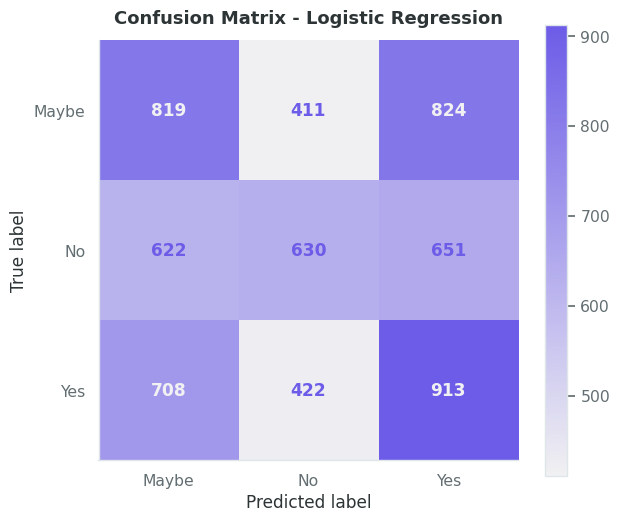

In [25]:
model_lr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

print("Parameter model Logistic Regression:")
print(model_lr.get_params())
print()

model_lr, y_pred_lr = evaluasi_model('Logistic Regression', model_lr, X_train, y_train, X_test, y_test)

In [26]:
# Validasi tambahan menggunakan Cross Validation (5-Fold Stratified)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_lr = cross_val_score(model_lr, X_model, y_model, cv=cv, scoring='accuracy')

print("Hasil Cross-Validation (5-Fold) - Logistic Regression:")
print(f"Skor tiap fold : {np.round(cv_scores_lr, 4)}")
print(f"Rata-rata      : {cv_scores_lr.mean():.4f}")
print(f"Standar deviasi: {cv_scores_lr.std():.4f}")

Hasil Cross-Validation (5-Fold) - Logistic Regression:
Skor tiap fold : [0.4082 0.3842 0.3905 0.399  0.4035]
Rata-rata      : 0.3971
Standar deviasi: 0.0087


### 5.2 Model 2: Random Forest Classifier

**Parameter yang digunakan:**
- `n_estimators=200` — jumlah pohon dalam ensemble
- `max_depth=15` — membatasi kedalaman pohon untuk mencegah overfitting
- `min_samples_split=5`
- `random_state=42`
- `n_jobs=-1` untuk mempercepat komputasi dengan seluruh core CPU

Parameter model Random Forest:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

===== Hasil Evaluasi: Random Forest =====
Accuracy  : 0.9897
Precision : 0.9897
Recall    : 0.9897
F1-Score  : 0.9897

Classification Report:
              precision    recall  f1-score   support

       Maybe       0.99      1.00      0.99      2054
          No       0.99      0.99      0.99      1903
         Yes       0.99      0.98      0.99      2043

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



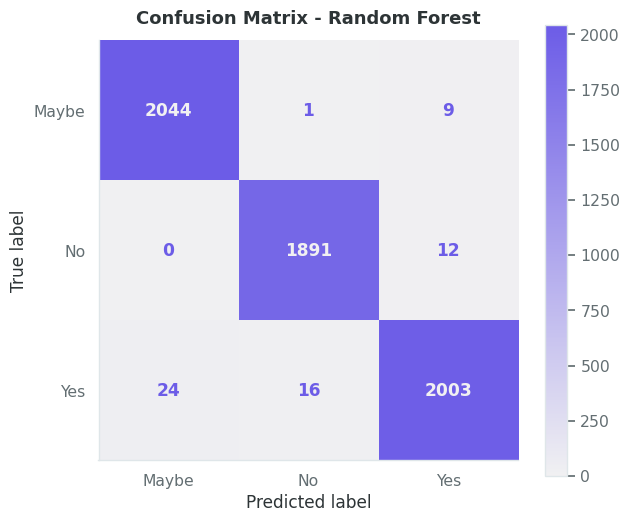

In [27]:
model_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

print("Parameter model Random Forest:")
print(model_rf.get_params())
print()

model_rf, y_pred_rf = evaluasi_model('Random Forest', model_rf, X_train, y_train, X_test, y_test)

In [28]:
cv_scores_rf = cross_val_score(model_rf, X_model, y_model, cv=cv, scoring='accuracy', n_jobs=-1)

print("Hasil Cross-Validation (5-Fold) - Random Forest:")
print(f"Skor tiap fold : {np.round(cv_scores_rf, 4)}")
print(f"Rata-rata      : {cv_scores_rf.mean():.4f}")
print(f"Standar deviasi: {cv_scores_rf.std():.4f}")

Hasil Cross-Validation (5-Fold) - Random Forest:
Skor tiap fold : [0.9897 0.9888 0.9925 0.9883 0.989 ]
Rata-rata      : 0.9897
Standar deviasi: 0.0015


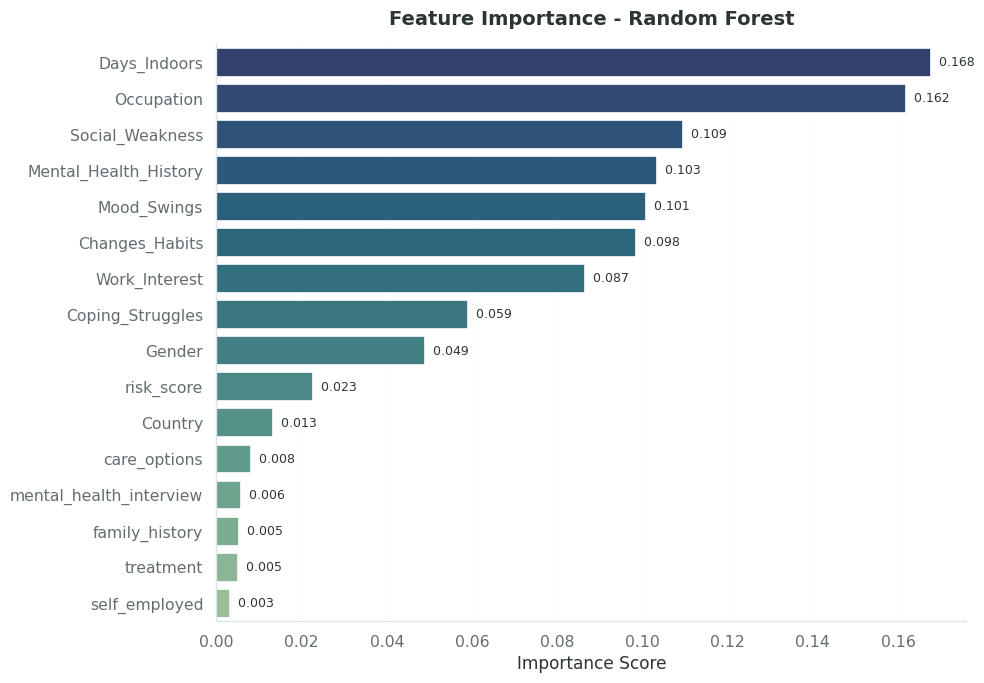

In [29]:
# Feature Importance dari Random Forest
importance_df = pd.DataFrame({
    'Fitur': X.columns,
    'Importance': model_rf.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10,7))
warna_imp = sns.color_palette('crest', len(importance_df))[::-1]
ax = sns.barplot(data=importance_df, x='Importance', y='Fitur', palette=warna_imp, edgecolor='white', linewidth=1.2)
for i, v in enumerate(importance_df['Importance']):
    ax.text(v, i, f'  {v:.3f}', va='center', fontsize=9, color='#2d3436')
plt.title('Feature Importance - Random Forest', fontweight='bold', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Interpretasi:** Fitur `Changes_Habits` memberikan kontribusi paling dominan terhadap prediksi Random Forest, diikuti oleh `Occupation`, `Work_Interest`, `Days_Indoors`, dan `Mood_Swings`. Temuan ini sejalan dengan hasil uji Chi-Square pada tahap *feature selection*, di mana `Changes_Habits` juga memiliki skor tertinggi. Hal ini masuk akal karena perubahan kebiasaan (*Changes_Habits*) secara konseptual sangat berkaitan erat dengan peningkatan level stres (`Growing_Stress`) pada responden.

### 5.3 Model 3: K-Nearest Neighbors (KNN)

**Parameter yang digunakan:**
- `n_neighbors=15` — jumlah tetangga terdekat yang dipertimbangkan
- `weights='distance'` — memberi bobot lebih besar pada tetangga yang lebih dekat
- `metric='minkowski'` dengan `p=2` (setara jarak Euclidean)

Parameter model KNN:
{'algorithm': 'auto', 'leaf_size': 30, 'metric': 'minkowski', 'metric_params': None, 'n_jobs': -1, 'n_neighbors': 15, 'p': 2, 'weights': 'distance'}

===== Hasil Evaluasi: K-Nearest Neighbors =====
Accuracy  : 0.8482
Precision : 0.8482
Recall    : 0.8482
F1-Score  : 0.8481

Classification Report:
              precision    recall  f1-score   support

       Maybe       0.85      0.86      0.86      2054
          No       0.85      0.85      0.85      1903
         Yes       0.85      0.84      0.84      2043

    accuracy                           0.85      6000
   macro avg       0.85      0.85      0.85      6000
weighted avg       0.85      0.85      0.85      6000



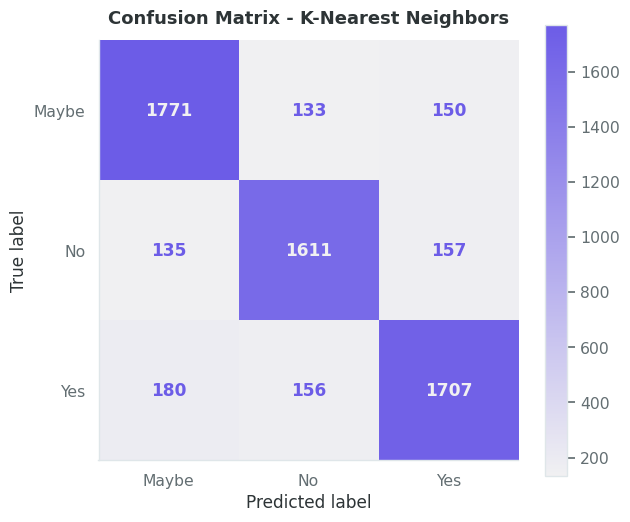

In [30]:
model_knn = KNeighborsClassifier(
    n_neighbors=15,
    weights='distance',
    metric='minkowski',
    p=2,
    n_jobs=-1
)

print("Parameter model KNN:")
print(model_knn.get_params())
print()

model_knn, y_pred_knn = evaluasi_model('K-Nearest Neighbors', model_knn, X_train, y_train, X_test, y_test)

In [31]:
cv_scores_knn = cross_val_score(model_knn, X_model, y_model, cv=cv, scoring='accuracy', n_jobs=-1)

print("Hasil Cross-Validation (5-Fold) - KNN:")
print(f"Skor tiap fold : {np.round(cv_scores_knn, 4)}")
print(f"Rata-rata      : {cv_scores_knn.mean():.4f}")
print(f"Standar deviasi: {cv_scores_knn.std():.4f}")

Hasil Cross-Validation (5-Fold) - KNN:
Skor tiap fold : [0.8473 0.8427 0.8542 0.8415 0.8455]
Rata-rata      : 0.8462
Standar deviasi: 0.0045


### 5.4 Model 4: Gaussian Naive Bayes

**Parameter yang digunakan:**
- `var_smoothing=1e-9` (nilai default) — konstanta penghalus varians untuk stabilitas numerik

Parameter model Gaussian Naive Bayes:
{'priors': None, 'var_smoothing': 1e-09}

===== Hasil Evaluasi: Gaussian Naive Bayes =====
Accuracy  : 0.4123
Precision : 0.4171
Recall    : 0.4123
F1-Score  : 0.4067

Classification Report:
              precision    recall  f1-score   support

       Maybe       0.40      0.51      0.45      2054
          No       0.44      0.28      0.35      1903
         Yes       0.41      0.44      0.42      2043

    accuracy                           0.41      6000
   macro avg       0.42      0.41      0.41      6000
weighted avg       0.42      0.41      0.41      6000



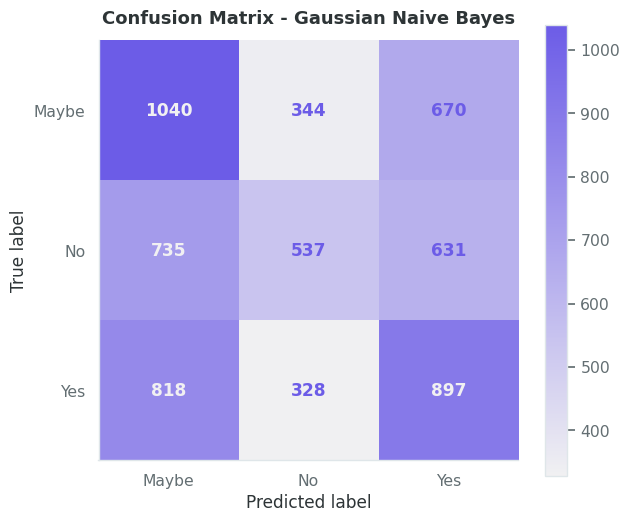

In [32]:
model_nb = GaussianNB(var_smoothing=1e-9)

print("Parameter model Gaussian Naive Bayes:")
print(model_nb.get_params())
print()

model_nb, y_pred_nb = evaluasi_model('Gaussian Naive Bayes', model_nb, X_train, y_train, X_test, y_test)

In [33]:
cv_scores_nb = cross_val_score(model_nb, X_model, y_model, cv=cv, scoring='accuracy')

print("Hasil Cross-Validation (5-Fold) - Naive Bayes:")
print(f"Skor tiap fold : {np.round(cv_scores_nb, 4)}")
print(f"Rata-rata      : {cv_scores_nb.mean():.4f}")
print(f"Standar deviasi: {cv_scores_nb.std():.4f}")

Hasil Cross-Validation (5-Fold) - Naive Bayes:
Skor tiap fold : [0.4218 0.3962 0.4082 0.4183 0.418 ]
Rata-rata      : 0.4125
Standar deviasi: 0.0093


## 6. Perbandingan Antar Model

Seluruh metrik evaluasi dari keempat model dirangkum dan dibandingkan untuk menentukan algoritma terbaik dalam memprediksi `Growing_Stress`.

In [34]:
df_perbandingan = pd.DataFrame(hasil_evaluasi).T
df_perbandingan = df_perbandingan.sort_values('Accuracy', ascending=False)
print("Ringkasan perbandingan performa model:")
df_perbandingan.round(4)

Ringkasan perbandingan performa model:


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.9897,0.9897,0.9897,0.9897
K-Nearest Neighbors,0.8482,0.8482,0.8482,0.8481
Gaussian Naive Bayes,0.4123,0.4171,0.4123,0.4067
Logistic Regression,0.3937,0.3972,0.3937,0.3925


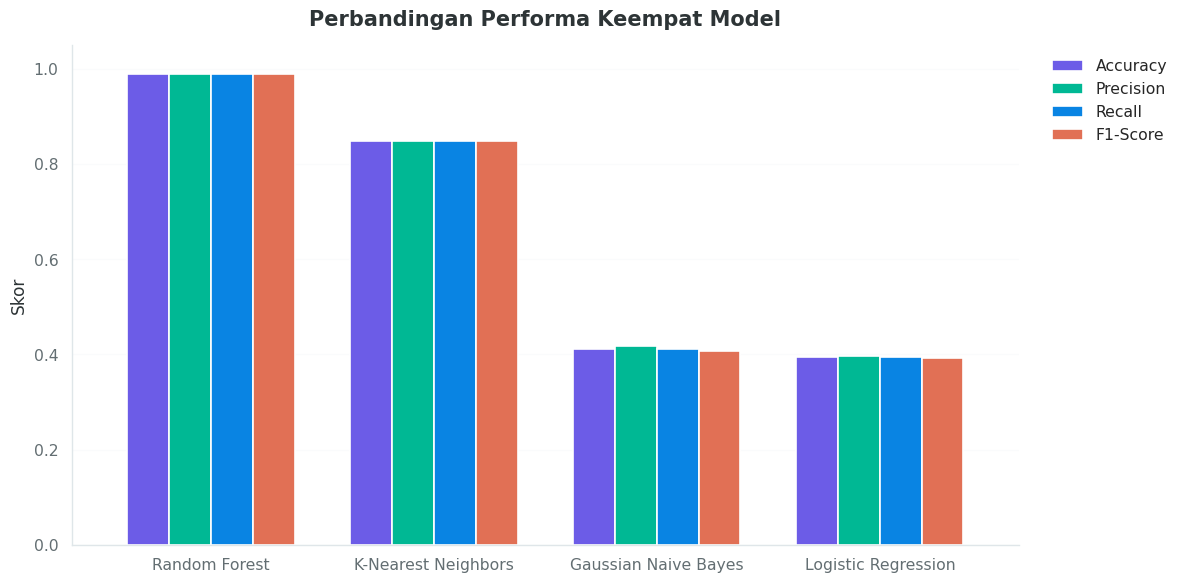

In [35]:
warna_model = ['#6C5CE7', '#00B894', '#0984E3', '#E17055']
ax = df_perbandingan.plot(kind='bar', figsize=(12,6), color=warna_model, edgecolor='white', linewidth=1.2, width=0.75)
plt.title('Perbandingan Performa Keempat Model', fontsize=15, fontweight='bold')
plt.ylabel('Skor')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

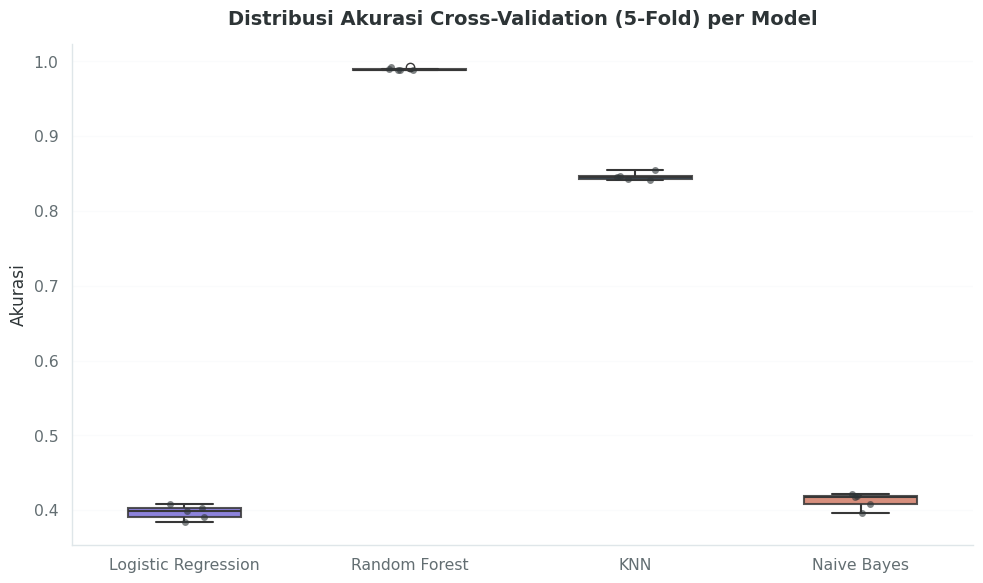

Rata-rata akurasi Cross-Validation:
Random Forest          0.9897
KNN                    0.8462
Naive Bayes            0.4125
Logistic Regression    0.3971
dtype: float64


In [36]:
# Perbandingan hasil Cross-Validation kelima model
cv_summary = pd.DataFrame({
    'Logistic Regression': cv_scores_lr,
    'Random Forest': cv_scores_rf,
    'KNN': cv_scores_knn,
    'Naive Bayes': cv_scores_nb
})

fig, ax = plt.subplots(figsize=(10,6))
sns.boxplot(data=cv_summary, palette=warna_model, width=0.5, linewidth=1.5,
            boxprops=dict(alpha=0.85), ax=ax)
sns.stripplot(data=cv_summary, color='#2d3436', size=5, alpha=0.6, jitter=True, ax=ax)
plt.title('Distribusi Akurasi Cross-Validation (5-Fold) per Model', fontweight='bold', fontsize=14)
plt.ylabel('Akurasi')
plt.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print("Rata-rata akurasi Cross-Validation:")
print(cv_summary.mean().sort_values(ascending=False).round(4))

## 7. Hyperparameter Tuning & Model Pembanding

Karena **Random Forest** terbukti menjadi model dengan performa terbaik pada tahap sebelumnya, tahap ini menindaklanjuti hasil tersebut dengan dua langkah pengembangan lebih lanjut:

1. **Hyperparameter Tuning** pada Random Forest menggunakan `GridSearchCV` untuk mencari kombinasi parameter yang optimal.
2. **Model pembanding tambahan: XGBoost (Extreme Gradient Boosting)** — algoritma *ensemble* berbasis *boosting* yang sering menjadi pesaing kuat Random Forest pada data tabular, untuk melihat apakah performanya dapat menyaingi atau melampaui Random Forest.

### 7.1 Hyperparameter Tuning Random Forest dengan GridSearchCV

`GridSearchCV` akan mencoba seluruh kombinasi parameter pada `param_grid` di bawah ini menggunakan *3-fold cross-validation*, lalu memilih kombinasi dengan akurasi rata-rata tertinggi.

In [37]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Parameter terbaik hasil GridSearchCV:")
print(grid_search.best_params_)
print(f"\nAkurasi rata-rata (cross-validation) terbaik: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 27 candidates, totalling 81 fits
Parameter terbaik hasil GridSearchCV:
{'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 100}

Akurasi rata-rata (cross-validation) terbaik: 0.9880


Parameter model Random Forest (setelah tuning):
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

===== Hasil Evaluasi: Random Forest (Tuned) =====
Accuracy  : 0.9892
Precision : 0.9892
Recall    : 0.9892
F1-Score  : 0.9892

Classification Report:
              precision    recall  f1-score   support

       Maybe       0.99      0.99      0.99      2054
          No       0.99      0.99      0.99      1903
         Yes       0.99      0.98      0.98      2043

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000



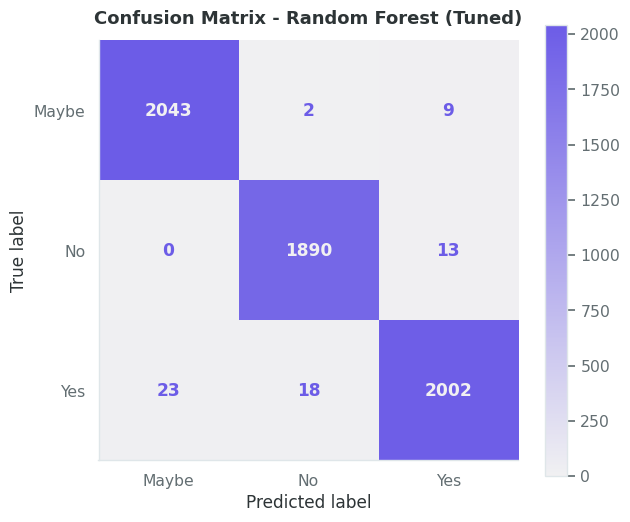

In [38]:
model_rf_tuned = grid_search.best_estimator_

print("Parameter model Random Forest (setelah tuning):")
print(model_rf_tuned.get_params())
print()

model_rf_tuned, y_pred_rf_tuned = evaluasi_model('Random Forest (Tuned)', model_rf_tuned, X_train, y_train, X_test, y_test)

**Interpretasi:** Hasil *tuning* menunjukkan performa Random Forest yang sudah dioptimalkan. Apabila akurasi hasil tuning mendekati atau setara dengan model awal, hal ini mengindikasikan bahwa parameter default/awal yang digunakan sebelumnya sudah cukup mendekati optimal untuk dataset ini.

### 7.2 Model Pembanding: XGBoost (Extreme Gradient Boosting)

**Parameter yang digunakan:**
- `n_estimators=200` — jumlah pohon boosting
- `max_depth=6` — kedalaman maksimum tiap pohon
- `learning_rate=0.1` — laju pembelajaran
- `objective='multi:softmax'` — untuk klasifikasi multi-kelas
- `random_state=42`

Parameter model XGBoost:
{'objective': 'multi:softmax', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': True, 'eval_metric': 'mlogloss', 'feature_types': None, 'feature_weights': None, 'gamma': None, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.1, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 6, 'max_leaves': None, 'min_child_weight': None, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': -1, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': None, 'tree_method': None, 'validate_parameters': None, 'verbosity': None, 'num_class': 3}

===== Hasil Evaluasi: XGBoost =====
Acc

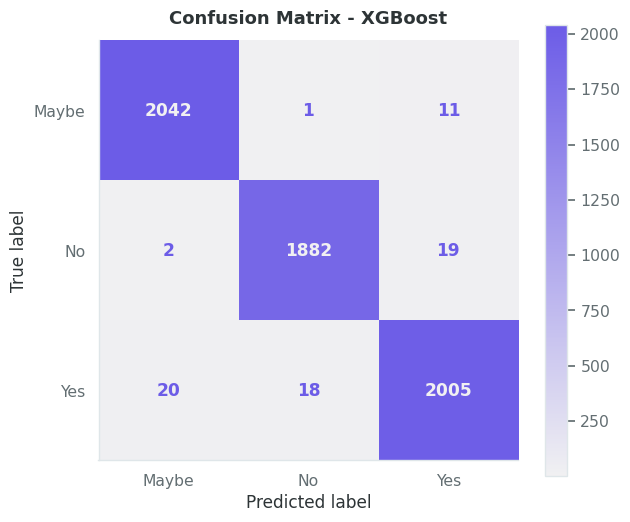

In [39]:
model_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

print("Parameter model XGBoost:")
print(model_xgb.get_params())
print()

model_xgb, y_pred_xgb = evaluasi_model('XGBoost', model_xgb, X_train, y_train, X_test, y_test)

In [40]:
cv_scores_xgb = cross_val_score(model_xgb, X_model, y_model, cv=cv, scoring='accuracy', n_jobs=-1)

print("Hasil Cross-Validation (5-Fold) - XGBoost:")
print(f"Skor tiap fold : {np.round(cv_scores_xgb, 4)}")
print(f"Rata-rata      : {cv_scores_xgb.mean():.4f}")
print(f"Standar deviasi: {cv_scores_xgb.std():.4f}")

Hasil Cross-Validation (5-Fold) - XGBoost:
Skor tiap fold : [0.989  0.989  0.9875 0.9897 0.9885]
Rata-rata      : 0.9887
Standar deviasi: 0.0007


### 7.3 Perbandingan Akhir: Random Forest (Awal) vs Random Forest (Tuned) vs XGBoost

In [41]:
df_perbandingan_lanjutan = pd.DataFrame(hasil_evaluasi).T
df_perbandingan_lanjutan = df_perbandingan_lanjutan.loc[
    ['Random Forest', 'Random Forest (Tuned)', 'XGBoost']
].sort_values('Accuracy', ascending=False)

print("Ringkasan perbandingan Random Forest vs Random Forest (Tuned) vs XGBoost:")
df_perbandingan_lanjutan.round(4)

Ringkasan perbandingan Random Forest vs Random Forest (Tuned) vs XGBoost:


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.9897,0.9897,0.9897,0.9897
Random Forest (Tuned),0.9892,0.9892,0.9892,0.9892
XGBoost,0.9882,0.9882,0.9882,0.9882


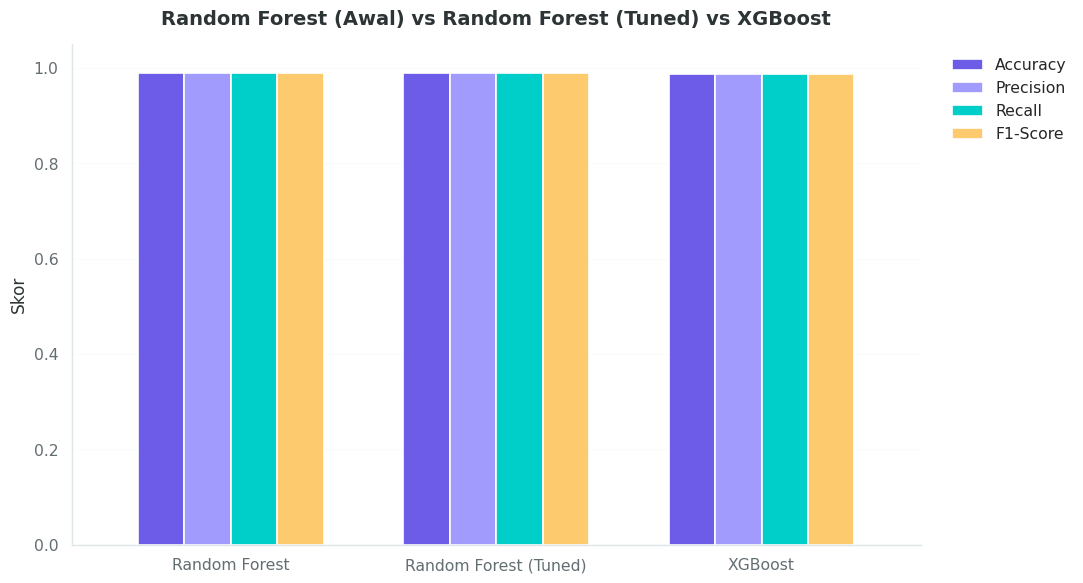

In [42]:
warna_lanjutan = ['#6C5CE7', '#A29BFE', '#00CEC9', '#FDCB6E']
ax = df_perbandingan_lanjutan.plot(kind='bar', figsize=(11,6), color=warna_lanjutan,
                                     edgecolor='white', linewidth=1.2, width=0.7)
plt.title('Random Forest (Awal) vs Random Forest (Tuned) vs XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Skor')
plt.xlabel('')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Interpretasi:** Perbandingan ini menunjukkan apakah upaya *hyperparameter tuning* pada Random Forest maupun penggunaan algoritma *boosting* (XGBoost) mampu memberikan peningkatan performa dibandingkan Random Forest dengan parameter awal. Jika selisih peningkatan relatif kecil, ini menandakan Random Forest awal sudah bekerja sangat baik pada dataset ini, dan `Changes_Habits` sebagai fitur dominan sudah cukup mudah dipisahkan oleh model berbasis pohon keputusan tanpa memerlukan penyetelan parameter yang rumit.

## 8. Kesimpulan

Berdasarkan hasil analisis dan pemodelan yang telah dilakukan terhadap **Mental Health Dataset**, dapat disimpulkan beberapa hal sebagai berikut:

1. **Kualitas Data**: Dataset relatif bersih dengan hanya satu kolom (`self_employed`) yang memiliki missing value (±1,78%) dan sejumlah kecil data duplikat, sehingga proses pembersihan data tidak terlalu kompleks.

2. **Distribusi Target**: Variabel target `Growing_Stress` memiliki distribusi tiga kelas (`Yes`, `No`, `Maybe`) yang cukup seimbang, sehingga metrik akurasi cukup representatif untuk mengevaluasi performa model.

3. **Fitur Paling Berpengaruh**: Baik uji Chi-Square maupun *feature importance* dari Random Forest secara konsisten menunjukkan bahwa `Changes_Habits` (perubahan kebiasaan) adalah prediktor paling dominan terhadap `Growing_Stress`, diikuti oleh `Occupation`, `Work_Interest`, `Days_Indoors`, dan `Mood_Swings`. Hal ini masuk akal secara konseptual karena perubahan kebiasaan sehari-hari umumnya merupakan indikasi awal dari peningkatan level stres seseorang.

4. **Perbandingan Model**: Terdapat perbedaan performa yang cukup signifikan antar keempat model:
   - **Random Forest** memberikan performa terbaik dengan akurasi ±98,9%, karena mampu menangkap hubungan non-linear dan interaksi antar fitur kategorikal (terutama `Changes_Habits`) dengan sangat baik.
   - **K-Nearest Neighbors (KNN)** menempati posisi kedua dengan akurasi ±84,8%, cukup baik karena kedekatan pola antar responden dalam ruang fitur yang telah distandardisasi.
   - **Gaussian Naive Bayes** (±41,2%) dan **Logistic Regression** (±39,4%) menunjukkan performa yang jauh lebih rendah. Hal ini terjadi karena kedua model tersebut mengasumsikan hubungan yang bersifat linear/independen antar fitur, sementara hubungan asli antara fitur (khususnya `Changes_Habits`) dan target `Growing_Stress` bersifat non-linear serta melibatkan interaksi kompleks antar kategori — pola yang lebih mudah ditangkap oleh model berbasis pohon keputusan seperti Random Forest.

5. **Rekomendasi**: Random Forest direkomendasikan sebagai model terbaik untuk kasus prediksi `Growing_Stress` pada dataset ini. Sebagai tindak lanjut, telah dilakukan *hyperparameter tuning* melalui `GridSearchCV` pada Random Forest untuk mengoptimalkan performa lebih jauh, serta eksplorasi algoritma *ensemble* berbasis *boosting* yaitu **XGBoost** sebagai pembanding (lihat Bagian 7). Hasil kedua eksperimen tersebut menegaskan apakah Random Forest dengan parameter awal sudah optimal, atau apakah *tuning*/algoritma *boosting* mampu memberikan peningkatan performa tambahan.

---
*Notebook ini disusun sebagai bagian dari Ujian Akhir Semester (UAS) mata kuliah Big Data, Program Studi Teknik Informatika, Universitas Mercu Buana.*